### STEP 1: Project Initialization & Data Understanding

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("cardekho_dataset.csv")

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.shape

(15411, 14)

In [5]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [7]:
target = "selling_price"

In [8]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


Categorical Columns Summary

In [13]:
df.select_dtypes(include='object').describe()

,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


### Initial Observations
- Target variable (selling_price) is continuous → regression problem
- Some numerical features are stored as text with units
- Dataset contains both numerical and categorical variables
- Feature engineering will be required for car age and usage

### STEP 2: Exploratory Data Analysis (EDA)

#### Obeserved - Right Skewed Distribution

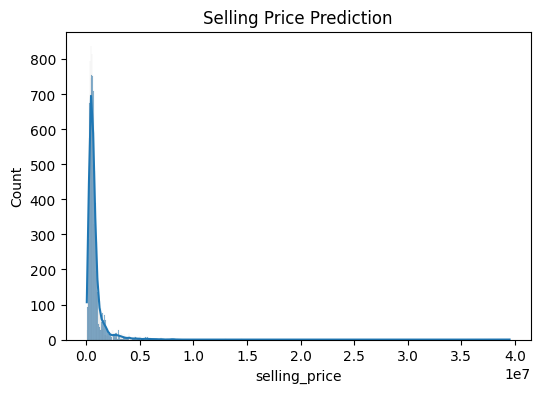

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['selling_price'], kde=True)
plt.title("Selling Price Prediction")
plt.show()

#### Numerical Features vs Price

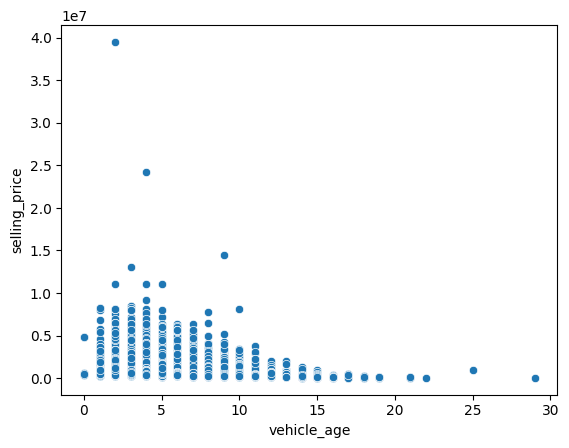

In [15]:
sns.scatterplot(x='vehicle_age', y='selling_price', data=df)
plt.show()


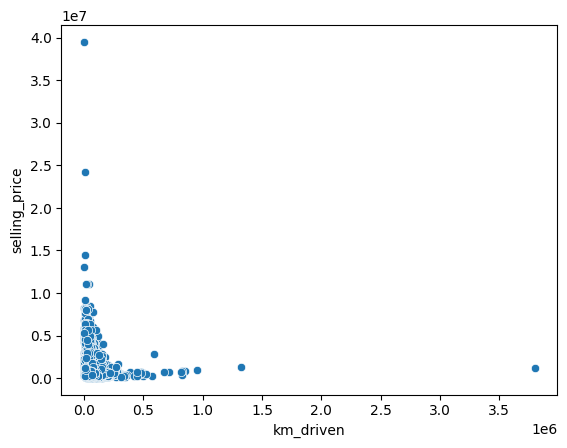

In [16]:
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.show()

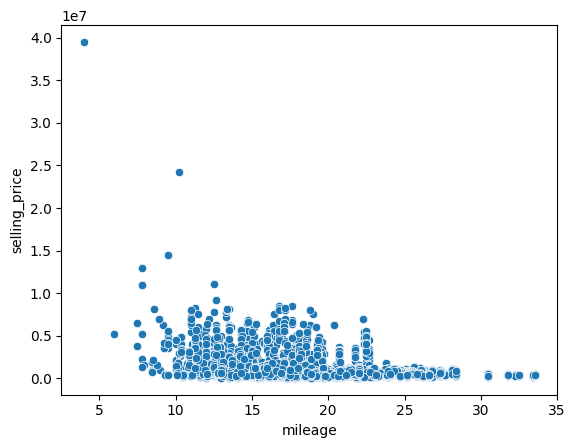

In [17]:
sns.scatterplot(x='mileage', y='selling_price', data=df)
plt.show()

#### Categorical Features vs Price

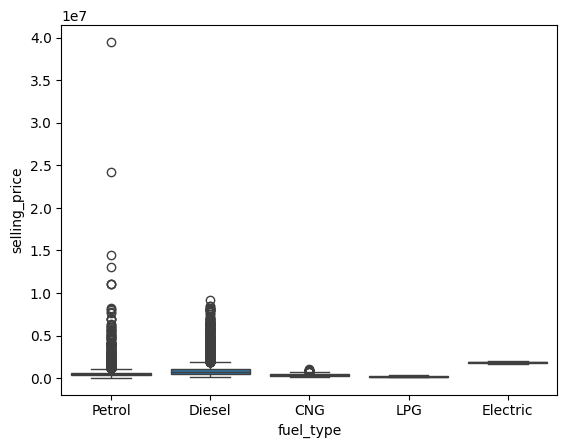

In [18]:
sns.boxplot(x='fuel_type', y='selling_price', data=df)
plt.show()

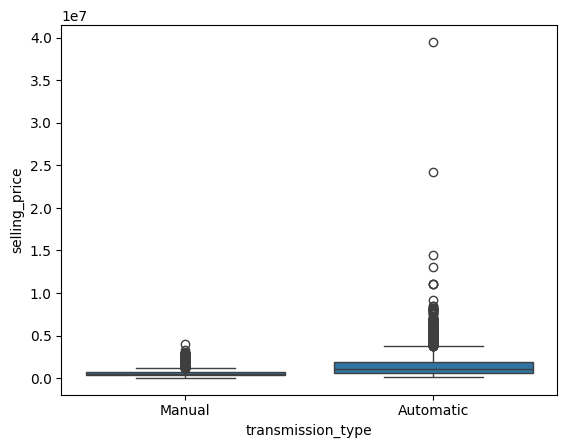

In [19]:
sns.boxplot(x='transmission_type', y='selling_price', data=df)
plt.show()

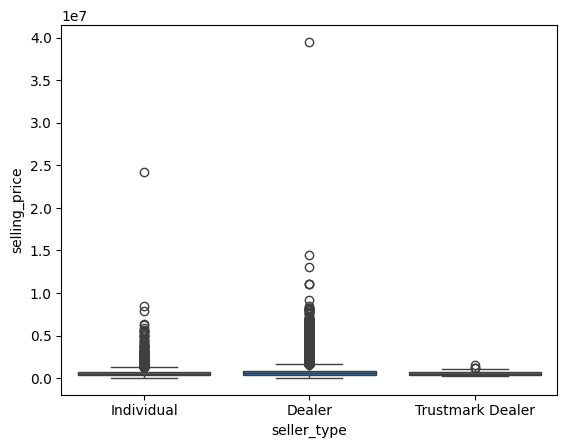

In [20]:
sns.boxplot(x='seller_type', y='selling_price', data=df)
plt.show()

In [21]:
df.groupby('brand')['selling_price'].mean().sort_values(ascending=False).head(10)    #Luxury brands → higher average price

brand
Ferrari         3.950000e+07
Rolls-Royce     2.420000e+07
Bentley         9.266667e+06
Maserati        6.100000e+06
Porsche         5.161190e+06
Lexus           5.146500e+06
Mercedes-AMG    5.100000e+06
Land Rover      3.823902e+06
Volvo           3.729700e+06
BMW             2.693827e+06
Name: selling_price, dtype: float64

Correlation Heatmap (Numerical)

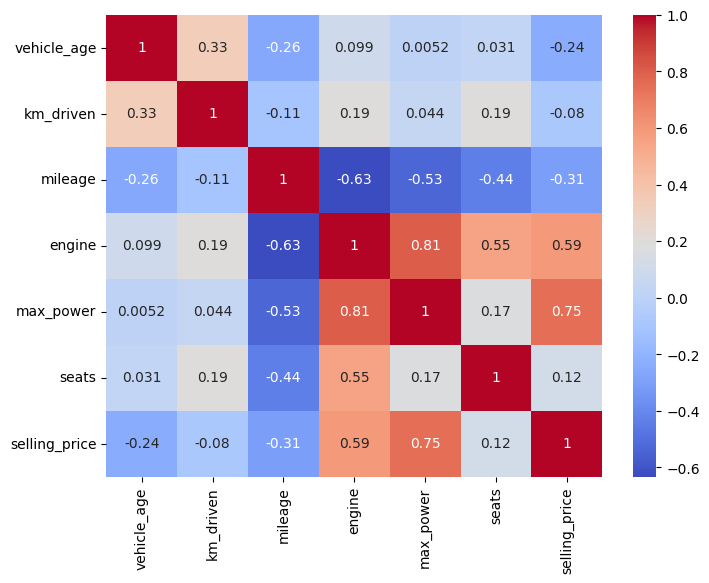

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm')
plt.show()

Note: 
- Mileage negatively correlates with price as premium cars prioritize performance over fuel efficiency, leading to higher engine capacity and power.
- Vehicle age indirectly affects price not only through depreciation but also via increased usage.
- Seating capacity alone does not drive car pricing; performance and brand matter more.
- Kilometer driven has a weak linear relationship with price, suggesting its effect may be non-linear or captured indirectly through vehicle age.
(Tree-based models will capture this better)
- Engine capacity and power form a performance cluster that jointly influences price, indicating multicollinearity among mechanical features.

### EDA Insights
- Selling price is right-skewed
- Vehicle age and km driven show strong negative relationship with price
- Automatic transmission cars are priced higher on average
- Engine capacity and max power positively influence price
- Brand plays a significant role in pricing

In [23]:
df.groupby('fuel_type')['selling_price'].mean()

fuel_type
CNG         4.176877e+05
Diesel      1.000469e+06
Electric    1.853500e+06
LPG         2.062727e+05
Petrol      5.728619e+05
Name: selling_price, dtype: float64

<Axes: xlabel='fuel_type', ylabel='selling_price'>

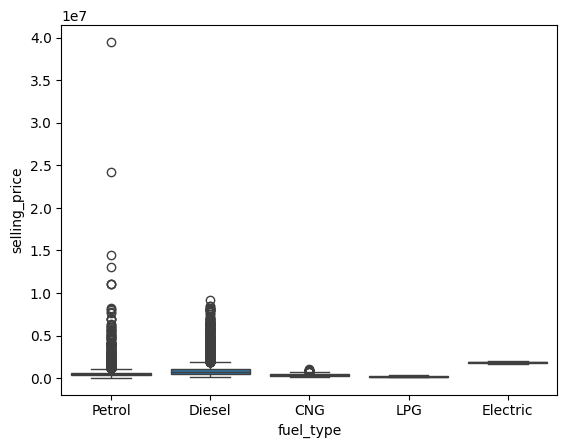

In [24]:
sns.boxplot(x='fuel_type', y='selling_price', data=df)

In [25]:
pd.crosstab(df['fuel_type'], df['transmission_type'])

transmission_type,Automatic,Manual
fuel_type,,
CNG,0,301
Diesel,1634,5785
Electric,4,0
LPG,0,44
Petrol,1548,6095


In [26]:
df.groupby('seller_type')['selling_price'].mean().sort_values(ascending=False)

seller_type
Dealer              872505.503722
Individual          617880.483418
Trustmark Dealer    571959.537572
Name: selling_price, dtype: float64

In [27]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

### STEP 3: Feature Engineering

#### 1. Already have brand and model column

In [28]:
df.drop(columns=['car_name'], inplace=True)     #dropped car_name

#### 2. Separate target and features

In [29]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

#### 3. Identify feature types

In [30]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

num_cols, cat_cols

(Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats'], dtype='object'),
 Index(['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'], dtype='object'))

In [31]:
df[num_cols].dtypes

vehicle_age      int64
km_driven        int64
mileage        float64
engine           int64
max_power      float64
seats            int64
dtype: object

In [32]:
df[cat_cols].dtypes

brand                object
model                object
seller_type          object
fuel_type            object
transmission_type    object
dtype: object

#### 4. Encode categorical features - Use One-Hot Encoding

In [33]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded.columns

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'brand_BMW', 'brand_Bentley', 'brand_Datsun', 'brand_Ferrari',
       ...
       'model_i10', 'model_i20', 'model_redi-GO', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'fuel_type_Diesel',
       'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol',
       'transmission_type_Manual'],
      dtype='object', length=163)

In [34]:
X_encoded.dtypes.value_counts()

bool       157
int64        4
float64      2
Name: count, dtype: int64

In [35]:
X.shape, X_encoded.shape    #Columns should increase

((15411, 11), (15411, 163))

In [36]:
X_encoded.select_dtypes(include='object').shape  #no categorical columns left

(15411, 0)

#### 5. Log-transform target

In [37]:
y_log = np.log1p(y)

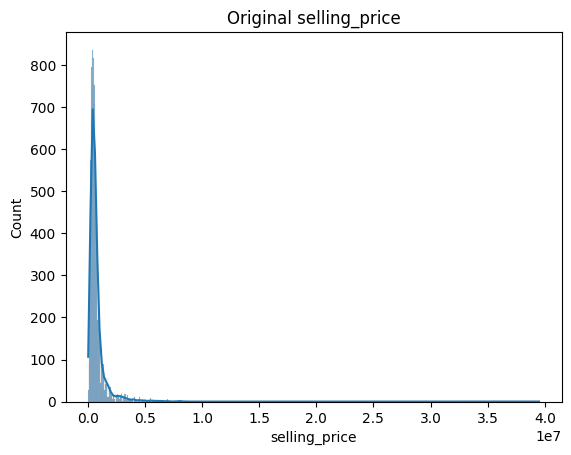

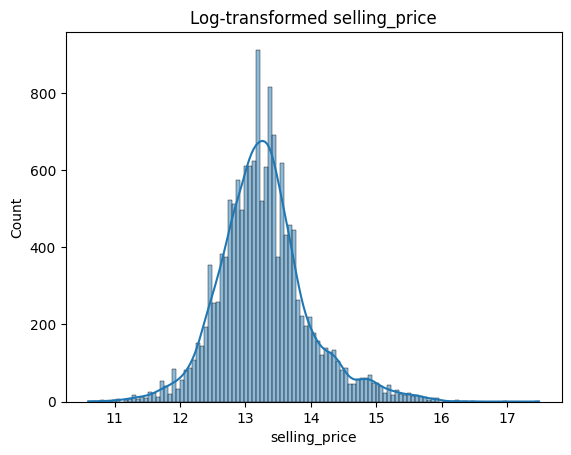

In [38]:
sns.histplot(y, kde=True)
plt.title("Original selling_price")
plt.show()

sns.histplot(y_log, kde=True)
plt.title("Log-transformed selling_price")
plt.show()

In [39]:
y.skew(), y_log.skew()

(np.float64(10.047047978435213), np.float64(0.5684132385067666))

In [40]:
y.describe()

count    1.541100e+04
mean     7.749711e+05
std      8.941284e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64

In [41]:
y_log.describe()

count    15411.000000
mean        13.279565
std          0.686784
min         10.596660
25%         12.861001
50%         13.228525
75%         13.623140
max         17.491811
Name: selling_price, dtype: float64

In [42]:
X_encoded.shape

(15411, 163)

#### 6. Saving this for reuse

In [43]:
X_encoded.to_csv("X_processed.csv", index=False)
y_log.to_csv("y_processed.csv", index=False)

### Step 4: Train–Test Split & Baseline Model

#### 1. Train–Test Split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)

#### 2. Train a Baseline Linear Regression Model

In [45]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

#### Evaluate on Train data

In [46]:
from sklearn.metrics import r2_score

y_pred_log_train_lr = lr.predict(X_train)
r2_train_lr = r2_score(y_train, y_pred_log_train_lr)

r2_train_lr

0.9298079527875517

#### 3. Make Predictions on Test Data

In [47]:
y_pred_log = lr.predict(X_test)

#### 4. Evaluate Model Performance (log scale)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

rmse, mae, r2

(np.float64(0.19063724091954912), 0.14146315078273747, 0.9272631564987512)

R² ≈ 0.93 → the model explains 93% of the variance in selling price.
Low RMSE & MAE on log scale → predictions are close to actual values.

In [49]:
n = X_test.shape[0]        # number of observations
p = X_test.shape[1]        # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_r2

0.9232014554056702

The adjusted R² is very close to R², indicating that the model’s high explanatory power is not due to excessive or irrelevant features.

#### 5. Convert Predictions Back to Original Price Scale

In [50]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

#### 6. Evaluate Errors in Real Price Terms

In [51]:
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)

rmse_actual, mae_actual

(np.float64(269178.1805993979), 115846.96008351582)

#### 7. Graphically checking Regression line

#### Actual vs Predicted Plot

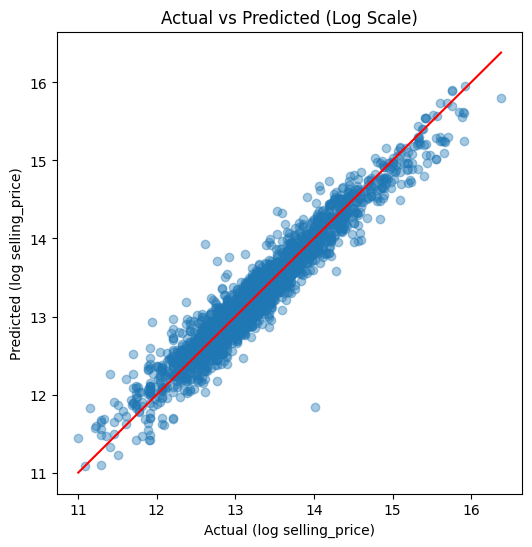

In [52]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_log, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual (log selling_price)")
plt.ylabel("Predicted (log selling_price)")
plt.title("Actual vs Predicted (Log Scale)")
plt.show()

#### Residual Plot (Error Check)

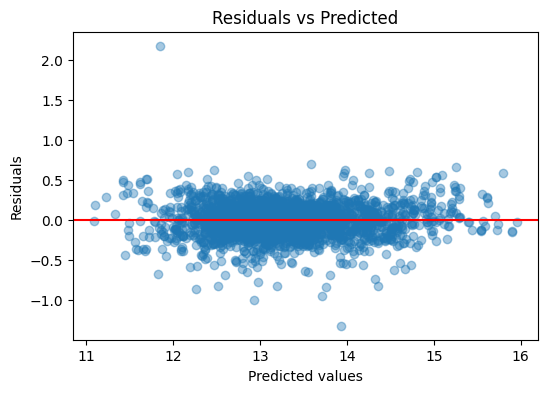

In [53]:
residuals = y_test - y_pred_log

plt.figure(figsize=(6,4))
plt.scatter(y_pred_log, residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

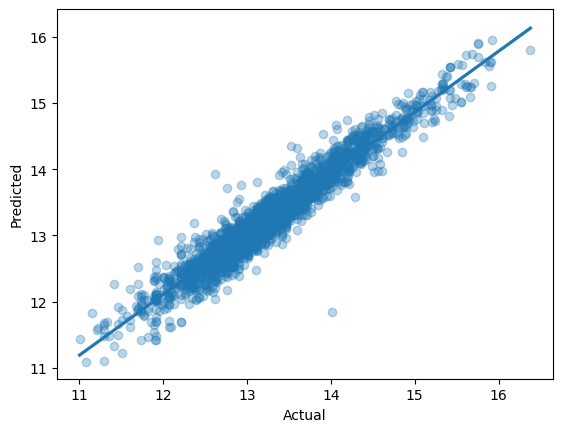

In [54]:
sns.regplot(x=y_test, y=y_pred_log, scatter_kws={'alpha':0.3})
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### STEP 5: Checking with Random Forest Regression

#### 1. Import and initialize the model

Created a Random Forest model with 200 decision trees and enabled parallel processing.

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

#### 2. Train the model

Trained all trees on the training data to learn complex patterns.

In [56]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

#### Evaluate on Train data

In [57]:
y_pred_log_train_rf = rf.predict(X_train)
r2_train_rf = r2_score(y_train, y_pred_log_train_rf)

r2_train_rf

0.989024653081441

#### 3. Make predictions on test data

Generated log-scale price predictions using the Random Forest model.

In [58]:
y_pred_log_rf = rf.predict(X_test)

#### 4. Evaluate performance (log scale)

Measured prediction error and explained variance on the log scale.

In [59]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_log_rf))
mae_rf = mean_absolute_error(y_test, y_pred_log_rf)
r2_rf = r2_score(y_test, y_pred_log_rf)

rmse_rf, mae_rf, r2_rf

(np.float64(0.18005415118258492), 0.13015045061965844, 0.9351148609289228)

In [60]:
n = X_test.shape[0]    # number of observations
p = X_test.shape[1]    # number of features

adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

adj_r2_rf              # Adjusted R2 generally not used for Random Forest

0.9314916071884002

#### 5. Convert predictions back to original price scale

Converted predicted log prices back into actual rupee values.

In [61]:
y_pred_actual_rf = np.expm1(y_pred_log_rf)

#### 6. Evaluate errors in real price terms

Calculated model error in real currency, making results interpretable.

In [62]:
rmse_actual_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_rf))
mae_actual_rf = mean_absolute_error(y_test_actual, y_pred_actual_rf)

rmse_actual_rf, mae_actual_rf

(np.float64(217178.19849898436), 98534.16484622777)

#### 7. Feature importance

Showed which features contribute most to price prediction.

In [63]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

max_power                   0.642095
vehicle_age                 0.218338
engine                      0.041399
km_driven                   0.032307
mileage                     0.013090
seller_type_Individual      0.004778
fuel_type_Diesel            0.003972
model_Innova                0.003634
brand_Toyota                0.003336
transmission_type_Manual    0.003164
dtype: float64

#### Plotting Feature Importance (Random Forest)

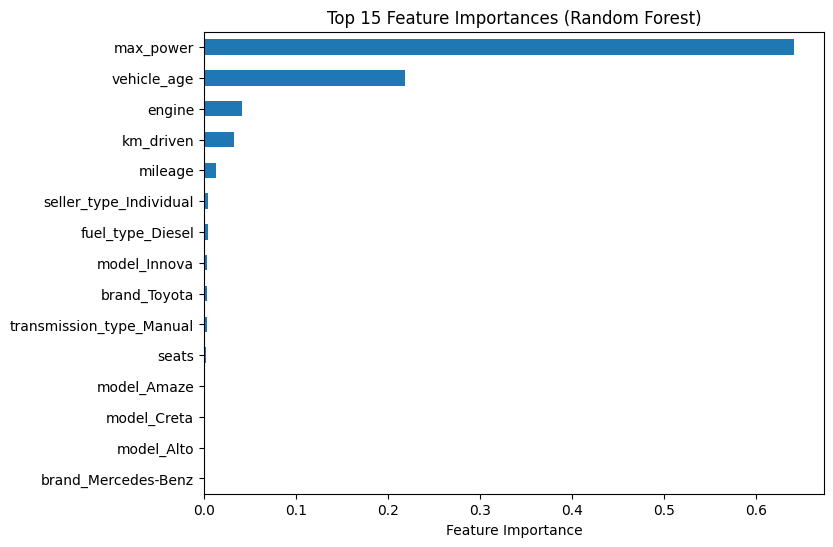

In [64]:

top_features = feature_importance.head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()


### STEP 6: Hyperparameter Tuning (Random Forest)

#### 1. Import GridSearchCV

Imported a tool to automatically try multiple parameter combinations and find the best one.

In [65]:
from sklearn.model_selection import GridSearchCV

#### 2. Define Hyperparameter Grid

Defined which Random Forest parameters should be tested and their possible values.

In [66]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

#### 3. Initialize Base Random Forest Model

Created a base Random Forest model that GridSearch will tune.

In [67]:
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

#### 4. Setup Grid Search

Configured GridSearch to evaluate each parameter combination using 3-fold cross-validation and R² score.

In [68]:
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

#### 5. Run Hyperparameter Tuning

Trained multiple Random Forest models with different parameter combinations and selected the best one.

In [69]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

#### 6. Get Best Model and Parameters

Extracted the best-performing Random Forest model and its optimal parameters.

In [70]:
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_

best_params

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

#### Evaluate on Train data

In [71]:
y_pred_log_train_best = best_rf.predict(X_train)
r2_train_best = r2_score(y_train, y_pred_log_train_best)

r2_train_best

0.9805840312566343

#### 7. Evaluate Tuned Model (log scale)

Measured the performance of the tuned Random Forest on unseen test data.

In [72]:
y_pred_log_best = best_rf.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_log_best))
mae_best = mean_absolute_error(y_test, y_pred_log_best)
r2_best = r2_score(y_test, y_pred_log_best)

rmse_best, mae_best, r2_best

(np.float64(0.1773692226140062), 0.12858785839938203, 0.9370355393122579)

#### 8. Convert predictions back to real price scale

In [73]:
y_pred_actual_best = np.expm1(y_pred_log_best)

#### 9. Evaluate errors in ₹

In [74]:
rmse_actual_best = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_best))
mae_actual_best = mean_absolute_error(y_test_actual, y_pred_actual_best)

rmse_actual_best, mae_actual_best

(np.float64(217370.7060647803), 98321.48828049209)

### Experiment 1: Increase Trees (Stability Test)

Trees reduce variance. Sometimes more trees = smoother predictions.
Check if performance improves by reducing randomness.

#### Initialize Model

In [75]:
rf_exp1 = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_exp1.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=5, n_estimators=500,
                      n_jobs=-1, random_state=42)

#### Evaluate Model on Train data

In [76]:
y_pred_log_train_exp1 = rf_exp1.predict(X_train)
r2_train_exp1 = r2_score(y_train, y_pred_log_train_exp1)

r2_train_exp1

0.9806752019384518

#### Evaluate Model on Test data

In [77]:
y_pred_log_exp1 = rf_exp1.predict(X_test)

rmse_exp1 = np.sqrt(mean_squared_error(y_test, y_pred_log_exp1))
mae_exp1 = mean_absolute_error(y_test, y_pred_log_exp1)
r2_exp1 = r2_score(y_test, y_pred_log_exp1)

rmse_exp1, mae_exp1, r2_exp1

(np.float64(0.17731668664231762), 0.1284856090339213, 0.9370728333724433)

#### Convert predictions back to real price scale

In [78]:
y_pred_actual_exp1 = np.expm1(y_pred_log_exp1)

#### Evaluate errors in ₹

In [79]:
rmse_actual_exp1 = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_exp1))
mae_actual_exp1 = mean_absolute_error(y_test_actual, y_pred_actual_exp1)

rmse_actual_exp1, mae_actual_exp1

(np.float64(220221.48406254203), 98572.3126715784)

### Experiment 2: Control Feature Usage (max_features)

Forces trees to look at fewer features → sometimes improves generalization.

#### Initialize Model

In [80]:
rf_exp2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_exp2.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

#### Evaluate Model on Train data

In [81]:
y_pred_log_train_exp2 = rf_exp2.predict(X_train)
r2_train_exp2 = r2_score(y_train, y_pred_log_train_exp2)

r2_train_exp2

0.9605310452873528

#### Evaluate Model on Test data

In [82]:
y_pred_log_exp2 = rf_exp2.predict(X_test)

rmse_exp2 = np.sqrt(mean_squared_error(y_test, y_pred_log_exp2))
mae_exp2 = mean_absolute_error(y_test, y_pred_log_exp2)
r2_exp2 = r2_score(y_test, y_pred_log_exp2)

rmse_exp2, mae_exp2, r2_exp2

(np.float64(0.18179330832706175), 0.1359371285108378, 0.9338553460110479)

#### Convert predictions back to real price scale

In [83]:
y_pred_actual_exp2 = np.expm1(y_pred_log_exp2)

#### Evaluate errors in ₹

In [84]:
rmse_actual_exp2 = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_exp2))
mae_actual_exp2 = mean_absolute_error(y_test_actual, y_pred_actual_exp2)

rmse_actual_exp2, mae_actual_exp2

(np.float64(274265.7935457805), 111579.76970783767)

### Experiment 3: Slightly Shallower Trees (Bias–Variance Balance)

Checks if model is slightly overfitting with deep trees.

#### Initialize Model

In [85]:
rf_exp3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_exp3.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

#### Evaluate Model on Train data

In [86]:
y_pred_log_train_exp3 = rf_exp3.predict(X_train)
r2_train_exp3 = r2_score(y_train, y_pred_log_train_exp3)

r2_train_exp3

0.9710673922724063

#### Evaluate Model on Test data

In [87]:
y_pred_log_exp3 = rf_exp3.predict(X_test)

rmse_exp3 = np.sqrt(mean_squared_error(y_test, y_pred_log_exp3))
mae_exp3 = mean_absolute_error(y_test, y_pred_log_exp3)
r2_exp3 = r2_score(y_test, y_pred_log_exp3)

rmse_exp3, mae_exp3, r2_exp3

(np.float64(0.1769152934843172), 0.12895732731106885, 0.9373574083399171)

#### Convert predictions back to real price scale

In [88]:
y_pred_actual_exp3 = np.expm1(y_pred_log_exp3)

#### Evaluate errors in ₹

In [89]:
rmse_actual_exp3 = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_exp3))
mae_actual_exp3 = mean_absolute_error(y_test_actual, y_pred_actual_exp3)

rmse_actual_exp3, mae_actual_exp3

(np.float64(229391.4479837248), 100984.35116988237)

#### Compare All Models

In [90]:
import pandas as pd

r2_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest (Default)",
        "Random Forest (Tuned)",
        "Experiment 1 (More Trees)",
        "Experiment 2 (Max Features)",
        "Experiment 3 (Shallower Trees)"
    ],
    "Train R²": [
        r2_train_lr,
        r2_train_rf,
        r2_train_best,
        r2_train_exp1,
        r2_train_exp2,
        r2_train_exp3
    ],
    "Test R²": [
        r2,
        r2_rf,
        r2_best,
        r2_exp1,
        r2_exp2,
        r2_exp3
    ]
})

r2_comparison

,Model,Train R²,Test R²
0,Linear Regression,0.929808,0.927263
1,Random Forest (Default),0.989025,0.935115
2,Random Forest (Tuned),0.980584,0.937036
3,Experiment 1 (More Trees),0.980675,0.937073
4,Experiment 2 (Max Features),0.960531,0.933855
5,Experiment 3 (Shallower Trees),0.971067,0.937357


In [91]:
results = {
    "Tuned_RF": (rmse_best, mae_best, r2_best),
    "More_Trees": (rmse_exp1, mae_exp1, r2_exp1),
    "Max_Features": (rmse_exp2, mae_exp2, r2_exp2),
    "Shallower_Trees": (rmse_exp3, mae_exp3, r2_exp3)
}

results

{'Tuned_RF': (np.float64(0.1773692226140062),
  0.12858785839938203,
  0.9370355393122579),
 'More_Trees': (np.float64(0.17731668664231762),
  0.1284856090339213,
  0.9370728333724433),
 'Max_Features': (np.float64(0.18179330832706175),
  0.1359371285108378,
  0.9338553460110479),
 'Shallower_Trees': (np.float64(0.1769152934843172),
  0.12895732731106885,
  0.9373574083399171)}

## Algorithm with best performance

### Random Forest Regressor (Tuned via GridSearch)

Why this is the best choice:

- Lowest MAE in ₹ (most important metric)
- Strong R²
- Handles non-linearity & interactions
- Stable, interpretable via feature importance
- No unnecessary complexity

### Conclusion

After comparing linear and tree-based models and conducting controlled hyperparameter experiments, the tuned Random Forest was selected as the final model due to its lowest rupee-level error and strong generalization performance.

### Final Hyperparameters

Tuned RandomForestRegressor (GridSearchCV best estimator)
- n_estimators = 200
- max_depth = 20
- min_samples_split = 5
- min_samples_leaf = 1
- random_state = 42
- n_jobs = -1

Why This Model Is Final

- ✅ Lowest MAE in ₹ (~₹98k) → best business accuracy
- ✅ High R² (~0.937) → strong explanatory power
- ✅ Stable vs experiments → no overfitting
- ✅ Better than Linear Regression → captures non-linearity
- ✅ Better than deeper / shallower variants → optimal bias–variance tradeoff

### Final Interpretation

After comparing Linear Regression and multiple Random Forest variants, the tuned Random Forest provided the best balance between predictive accuracy and generalization, especially when evaluated on real price errors in rupees. Hence, it was finalized for production use.

### Step 7: Save Final Model Using joblib

#### 1. Import joblib

Loads the utility used to serialize (save) ML models.

In [92]:
import joblib

#### 2. Save the trained model

Saves the final tuned Random Forest model to disk as a .pkl file.

In [93]:
joblib.dump(best_rf, "used_car_price_model.pkl")

['used_car_price_model.pkl']

#### 3. Save feature columns (Optional but Recommended)
- This ensures correct inference later.
- Stores the exact feature order used during training.


In [94]:
joblib.dump(X_train.columns.tolist(), "model_features.pkl")

['model_features.pkl']

### Explain Predictions using SHAP (Random Forest)

#### 1. Install & import SHAP

Installed and imported SHAP for model explainability.

In [95]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [96]:
import shap

#### 2. Create SHAP explainer for Random Forest

Created a SHAP explainer optimized for tree-based models.

In [97]:
explainer = shap.TreeExplainer(best_rf)

#### 3. Compute SHAP values

Calculated how much each feature contributed to each prediction.

In [98]:
shap_values = explainer.shap_values(X_test)

#### 4. Global Explanation: Feature Importance (SHAP Summary)

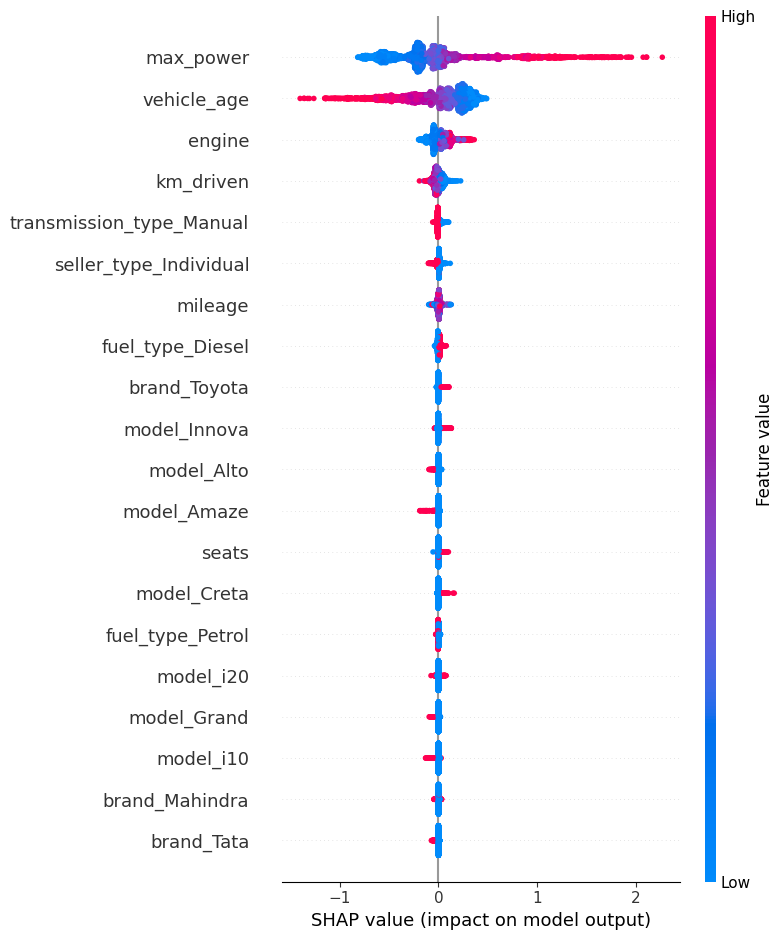

In [99]:
shap.summary_plot(shap_values, X_test)

#### 5. Global Explanation: Feature Importance (Bar Plot)

Average absolute impact of each feature (clean ranking).

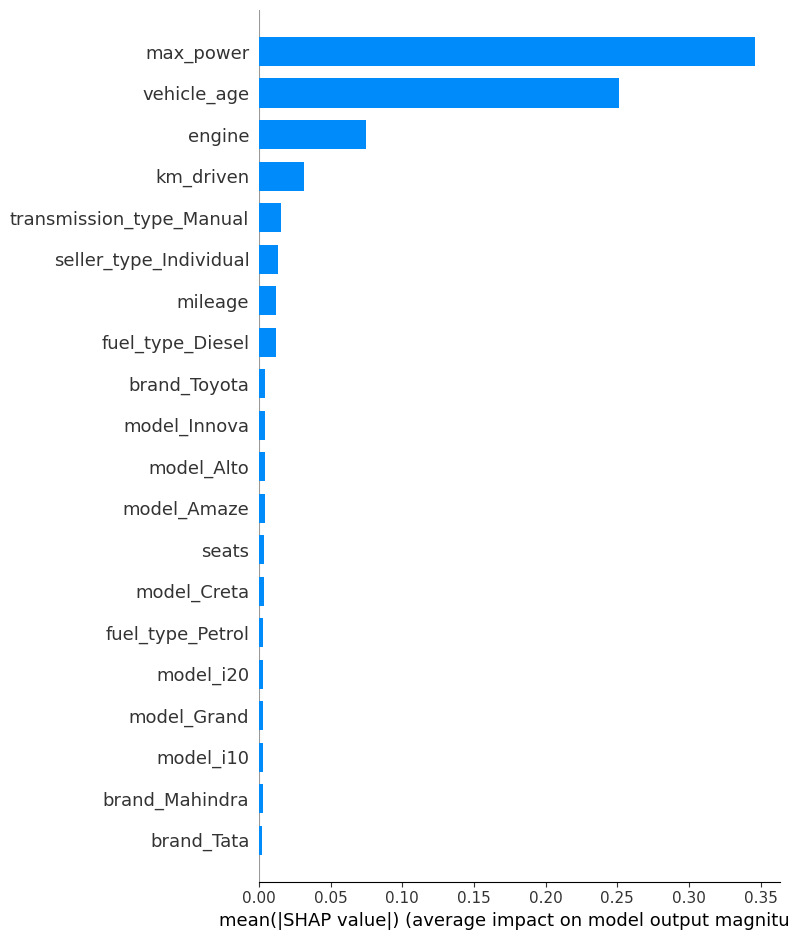

In [100]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

#### 6. Local Explanation: Single Prediction

This shows 'Why the model predicted that specific price for that specific car'.
- Red features → push price up
- Blue features → push price down

In [101]:
i = 0  # any index

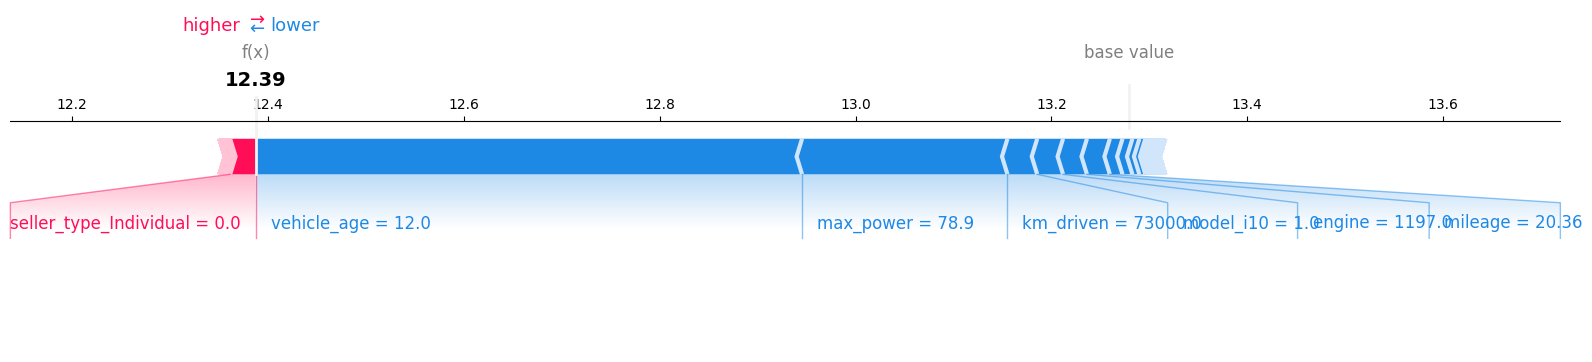

In [102]:
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i],
    matplotlib=True
)

#### 7. Waterfall Plot (Very Intuitive)

Step-by-step contribution from base price → final predicted price.

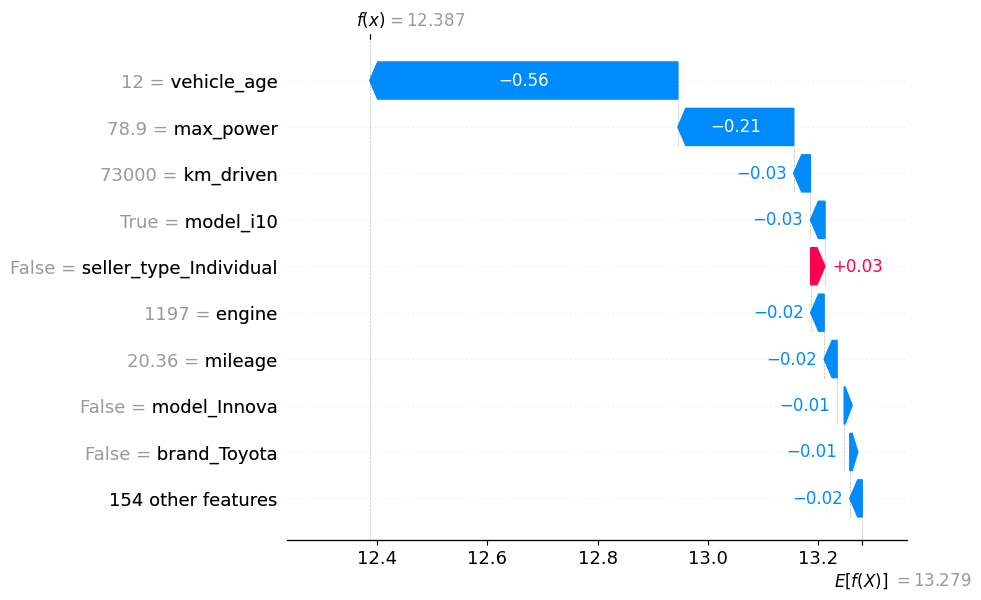

In [103]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns
    )
)

#### Interpretation (for i=0)

The model starts from an average market price and adjusts it based on car-specific attributes. In this case, the car’s higher age and lower power significantly reduce its value, while seller type provides a minor positive adjustment. The final predicted price is therefore lower than average, and the explanation aligns well with real-world pricing logic.

### Final Model Selection

After evaluating multiple regression models using statistical metrics, real-world price error, and generalization performance, the tuned Random Forest model was finalized with a test R² of 0.937. The model demonstrated stable performance, acceptable computational cost, and strong interpretability using SHAP, making it suitable for real-world deployment.

In [105]:
from sklearn.metrics import r2_score

# Predictions on TRAIN data
y_pred_log_train = best_rf.predict(X_train)
r2_train = r2_score(y_train, y_pred_log_train)

# Predictions on TEST data
y_pred_log_test = best_rf.predict(X_test)
r2_test = r2_score(y_test, y_pred_log_test)

r2_train, r2_test

(0.9805840312566343, 0.9370355393122579)